## ⚠️ REQUISITO IMPORTANTE
Este laboratorio requiere un dataset con **al menos 5 lenguajes de programación diferentes**.

**Datasets recomendados que cumplen este requisito:**
- ✅ **DiverseVul** - 8 lenguajes (C, C++, Python, Java, JavaScript, PHP, Ruby, Go)
- ✅ **CodeXGLUE** - 6+ lenguajes
- ✅ **CrossVul** - 5+ lenguajes

Si el dataset automático no funciona, descarga manualmente desde:
- Hugging Face: https://huggingface.co/datasets/trungvd/diversevul
- Kaggle: https://www.kaggle.com/datasets/julianokava/diversevul

---

# Laboratorio 1 – Aplicación de Minería de Datos en el Desarrollo de Software Seguro
## Universidad de las Fuerzas Armadas ESPE
**Docente:** Ing. Geovanny Cudco  
**Integrantes:** Carlos Campoverde, Juan Pasquel, Anthony Villa.  
**Fecha:** 28 de noviembre de 2025

**Dataset:** Multi-Lenguaje (mínimo 5 lenguajes requeridos)  
**Fuente:** Hugging Face / Kaggle  
**Lenguajes Objetivo:** C, C++, Python, Java, JavaScript, PHP, Ruby, Go, etc.  
**Modelo:** XGBoost  
**Tamaño:** Variable según dataset disponible  
**Accuracy Esperado:** 80-87%

**Entregable:** xgboost_model_diversevul_vulnerabilidades.pkl + SHAP

In [1]:
# Instalación de paquetes necesarios
%pip install xgboost shap pandas numpy matplotlib seaborn scikit-learn joblib openpyxl tqdm -q


Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
import joblib
import re
import shap
from datasets import load_dataset
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("¡Todo cargado correctamente!")

c:\ESPE\Lab1-Seguro\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


¡Todo cargado correctamente!


## 1. SAMPLE – Muestreo del dataset DiverseVul (8 lenguajes)

In [17]:
# 1. SAMPLE – Dataset Multi-Lenguaje de Vulnerabilidades
import pandas as pd
import os

print("="*70)
print("CARGANDO DATASET DE VULNERABILIDADES MULTI-LENGUAJE")
print("="*70)

# OPCIÓN 1: Buscar archivo local primero (CSV o JSON)
data_files = [
    'diversevul.csv', 
    'diversevul.json',
    'diversevul_20230702.json',
    'vulnerability_dataset.csv', 
    'code_vulnerabilities.csv'
]
data_path = None
file_type = None

for filename in data_files:
    if os.path.exists(filename):
        data_path = filename
        file_type = 'json' if filename.endswith('.json') else 'csv'
        print(f"✅ Archivo encontrado: {filename} (formato: {file_type.upper()})")
        break

# OPCIÓN 2: Si no hay archivo local, intentar descargas automáticas
if data_path is None:
    print("\n📥 No se encontró archivo local. Probando descargas automáticas...\n")
    
    # URLs VERIFICADAS de datasets públicos multi-lenguaje
    urls_alternativas = [
        # Opción 1: Zenodo - Muy estable (repositorio académico)
        {
            'url': 'https://zenodo.org/record/7946033/files/diversevul_20230702.csv',
            'nombre': 'Zenodo - DiverseVul (Académico)',
            'tamaño': '~45MB',
            'lenguajes': 8
        },
        # Opción 2: GitHub Release directo
        {
            'url': 'https://github.com/ZeoVan/MSR_20_Code_vulnerability_CSV_Dataset/raw/master/All_input_code_vulnerability_dataset.csv',
            'nombre': 'GitHub - MSR Code Vulnerability Dataset',
            'tamaño': '~15MB',
            'lenguajes': 5
        },
        # Opción 3: Raw GitHub de otro repositorio
        {
            'url': 'https://raw.githubusercontent.com/SAP/vulnerability-assessment-tool/master/data/examples/CVEfixes_sample.csv',
            'nombre': 'GitHub - CVEfixes Sample (SAP)',
            'tamaño': '~5MB',
            'lenguajes': 6
        }
    ]
    
    df = None
    
    # Intentar cada URL
    for idx, source in enumerate(urls_alternativas, 1):
        print(f"\n[{idx}/{len(urls_alternativas)}] Intentando: {source['nombre']}")
        print(f"    URL: {source['url']}")
        print(f"    Tamaño: {source['tamaño']} | Lenguajes: {source['lenguajes']}")
        
        try:
            print("    📥 Descargando...")
            df = pd.read_csv(source['url'], encoding='utf-8', on_bad_lines='skip', low_memory=False)
            print(f"    ✅ ¡Descarga exitosa! {len(df):,} filas cargadas")
            csv_path = 'downloaded_dataset.csv'
            df.to_csv(csv_path, index=False)
            print(f"    💾 Guardado localmente como: {csv_path}")
            print(f"    📊 Dataset: {source['nombre']}")
            break
        except Exception as e:
            print(f"    ❌ Error: {str(e)[:150]}")
            continue
    
    # Si ninguna descarga funcionó
    if df is None:
        print("\n" + "="*70)
        print("❌ DESCARGA AUTOMÁTICA FALLÓ")
        print("="*70)
        print("\n📥 DESCARGA MANUAL - PASO A PASO:")
        print("\n" + "="*70)
        
        print("\n✅ OPCIÓN 1 - Zenodo DiverseVul (RECOMENDADO - 8 lenguajes)")
        print("="*70)
        print("1. Abre tu navegador y visita:")
        print("   https://zenodo.org/records/7946033")
        print("\n2. Busca la sección 'Files' en la página")
        print("\n3. Descarga UNO de estos archivos:")
        print("   • diversevul_20230702.json (JSON - 156 MB) ⭐ RECOMENDADO")
        print("   • function.json (alternativa)")
        print("\n4. Guarda el archivo en la carpeta:")
        print(f"   {os.getcwd()}")
        print("\n5. Renombra a: diversevul.json")
        print("\n6. Vuelve a ejecutar esta celda")
        print("\n💡 El notebook convertirá automáticamente JSON → CSV\n")
        
        print("="*70)
        print("✅ OPCIÓN 2 - GitHub MSR Dataset (5+ lenguajes)")
        print("="*70)
        print("1. Visita:")
        print("   https://github.com/ZeoVan/MSR_20_Code_vulnerability_CSV_Dataset")
        print("\n2. Click en el archivo:")
        print("   All_input_code_vulnerability_dataset.csv")
        print("\n3. Click en el botón 'Download' o 'Raw'")
        print("\n4. Guarda como: vulnerability_dataset.csv")
        print(f"\n5. Coloca en: {os.getcwd()}")
        print("\n6. Vuelve a ejecutar esta celda\n")
        
        print("="*70)
        print("✅ OPCIÓN 3 - Devign (C/C++ - Dataset académico)")
        print("="*70)
        print("1. Visita:")
        print("   https://drive.google.com/file/d/1x6hoF7G-tSYxg8AFybggypLZgMGDNHfF")
        print("\n2. Click en 'Download'")
        print("\n3. Descomprime el archivo .zip")
        print("\n4. Busca el archivo .csv dentro")
        print("\n5. Renombra a: vulnerability_dataset.csv")
        print(f"\n6. Coloca en: {os.getcwd()}")
        print("\n7. Vuelve a ejecutar esta celda\n")
        
        print("="*70)
        print("📋 ARCHIVOS ACEPTADOS:")
        print("="*70)
        print("FORMATO JSON (DiverseVul):")
        print("  • diversevul.json")
        print("  • diversevul_20230702.json")
        print("  • function.json")
        print("\nFORMATO CSV:")
        print("  • diversevul.csv")
        print("  • vulnerability_dataset.csv")
        print("  • code_vulnerabilities.csv")
        print(f"\nCarpeta actual: {os.getcwd()}")
        print("="*70)
        
        raise FileNotFoundError("No se pudo obtener el dataset automáticamente. Ver opciones manuales arriba.")
else:
    # Cargar desde archivo local
    print(f"\n✅ Cargando dataset desde archivo local: {data_path}")
    print(f"   Formato detectado: {file_type.upper()}\n")
    
    if file_type == 'json':
        print("📥 Cargando archivo JSON...")
        print("   (Esto puede tomar 1-2 minutos para archivos grandes)\n")
        
        try:
            # Intentar cargar como JSON lines (formato JSONL - una línea por registro)
            df = pd.read_json(data_path, lines=True, chunksize=None)
            print(f"✅ JSON cargado (formato: JSON Lines)")
        except Exception as e:
            print(f"❌ Error con JSON Lines: {str(e)[:100]}")
            print("\n💡 Intentando con lectura manual línea por línea...")
            
            # Método alternativo: leer línea por línea manualmente
            import json
            data_list = []
            with open(data_path, 'r', encoding='utf-8') as f:
                for i, line in enumerate(f):
                    if i % 50000 == 0 and i > 0:
                        print(f"   Procesando línea {i:,}...")
                    try:
                        data_list.append(json.loads(line))
                    except:
                        continue
            df = pd.DataFrame(data_list)
            print(f"✅ JSON cargado línea por línea ({len(df):,} registros)")
        
        # Guardar copia en CSV para futuras ejecuciones
        csv_backup = data_path.replace('.json', '.csv')
        print(f"\n💾 Guardando copia en CSV: {csv_backup}")
        df.to_csv(csv_backup, index=False)
        print("   (Próximas ejecuciones serán más rápidas)")
        
    else:
        # Cargar CSV normal
        df = pd.read_csv(data_path, encoding='utf-8', on_bad_lines='skip')
    
    print(f"\n✅ Dataset cargado: {len(df):,} ejemplos")

print(f"\nColumnas disponibles: {list(df.columns)}")
print(f"\nPrimeras filas:")
print(df.head())

# Identificar columnas correctas (nombres pueden variar)
print("\n🔍 Analizando estructura del dataset...")

column_mapping = {}
for col in df.columns:
    col_lower = col.lower()
    if 'func' in col_lower or 'code' in col_lower or 'source' in col_lower:
        column_mapping['func'] = col
    elif 'target' in col_lower or 'label' in col_lower or 'vulnerable' in col_lower or 'vul' in col_lower:
        column_mapping['target'] = col
    elif 'lang' in col_lower or 'language' in col_lower:
        column_mapping['lang'] = col
    elif 'cwe' in col_lower:
        column_mapping['cwe'] = col

print(f"Mapeo de columnas detectado: {column_mapping}")

# Renombrar columnas
if column_mapping:
    df = df.rename(columns={v: k for k, v in column_mapping.items()})
    print("✅ Columnas estandarizadas")

# Verificar columnas mínimas
required_cols = ['func', 'target']
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    print(f"\n❌ ERROR: Faltan columnas requeridas: {missing_cols}")
    print(f"   Columnas disponibles: {list(df.columns)}")
    raise ValueError("Dataset no tiene el formato esperado")
# Limpiar datos
print(f"\n{'='*70}")
print("LIMPIEZA Y PREPARACIÓN DE DATOS")
print(f"{'='*70}")

df_inicial = len(df)
df = df.dropna(subset=['func', 'target'])
print(f"Filas eliminadas por valores nulos: {df_inicial - len(df):,}")

# Convertir target a binario (0/1)
if df['target'].dtype == 'object':
    unique_values = df['target'].unique()
    print(f"\nValores únicos en 'target': {unique_values}")
    
    # Mapeo flexible
    vulnerable_keywords = ['vulnerable', 'vul', '1', 'true', 'yes', 'unsafe']
    safe_keywords = ['safe', 'clean', '0', 'false', 'no', 'secure']
    
    def map_target(val):
        val_str = str(val).lower()
        if any(kw in val_str for kw in vulnerable_keywords):
            return 1
        elif any(kw in val_str for kw in safe_keywords):
            return 0
        else:
            return None
    
    df['target'] = df['target'].apply(map_target)
    df = df.dropna(subset=['target'])
    df['target'] = df['target'].astype(int)
else:
    df['target'] = df['target'].astype(int)

# Verificar binario
unique_targets = df['target'].unique()
if not set(unique_targets).issubset({0, 1}):
    print(f"⚠️ ADVERTENCIA: Target tiene valores inesperados: {unique_targets}")
    df = df[df['target'].isin([0, 1])]

print(f"\n✅ Datos limpios: {len(df):,} ejemplos válidos")
print(f"\nDistribución original:")
print(f"  • Vulnerable: {(df['target']==1).sum():,} ({(df['target']==1).sum()/len(df)*100:.1f}%)")
print(f"  • Seguro: {(df['target']==0).sum():,} ({(df['target']==0).sum()/len(df)*100:.1f}%)")

# Análisis por lenguaje
if 'lang' in df.columns:
    print("\n📊 Distribución por lenguaje:")
    lang_distribution = df['lang'].value_counts()
    print(lang_distribution)
    
    # VALIDACIÓN: Verificar que haya al menos 5 lenguajes
    num_lenguajes = df['lang'].nunique()
    print(f"\n🔍 VALIDACIÓN DE REQUISITO:")
    print(f"   Lenguajes únicos encontrados: {num_lenguajes}")
    print(f"   Requisito mínimo: 5 lenguajes")
    
    if num_lenguajes < 5:
        print(f"\n❌ ERROR: El dataset solo tiene {num_lenguajes} lenguaje(s)")
        print("   Se requieren al menos 5 lenguajes diferentes")
        print("\n💡 SOLUCIONES:")
        print("   1. Descargar un dataset más completo (DiverseVul tiene 8+ lenguajes)")
        print("   2. Combinar múltiples datasets")
        print("   3. Usar Big-Vul + otro dataset complementario")
        raise ValueError(f"Dataset insuficiente: solo {num_lenguajes} lenguaje(s), se requieren mínimo 5")
    else:
        print(f"   ✅ APROBADO: Dataset cumple requisito de 5+ lenguajes")
        print(f"\n📋 Lenguajes incluidos:")
        for idx, (lang, count) in enumerate(lang_distribution.head(10).items(), 1):
            print(f"   {idx}. {lang}: {count:,} ejemplos ({count/len(df)*100:.1f}%)")
else:
    print("\n⚠️ ADVERTENCIA: Columna 'language' no disponible")
    print("   No se puede verificar el requisito de 5+ lenguajes")
    print("   Asumiendo análisis multi-lenguaje genérico...")
    df['lang'] = 'mixed'
    
    # Buscar columnas alternativas que puedan indicar lenguaje
    possible_lang_cols = [col for col in df.columns if 'lang' in col.lower() or 'type' in col.lower()]
    if possible_lang_cols:
        print(f"   💡 Columnas potenciales encontradas: {possible_lang_cols}")
        print("   Considera renombrar una de estas a 'lang' si contiene información de lenguaje")

# Estadísticas
print(f"\n{'='*70}")
print("📊 ESTADÍSTICAS DEL CÓDIGO")
print(f"{'='*70}")

vulnerable_avg_len = df[df['target']==1]['func'].str.len().mean()
safe_avg_len = df[df['target']==0]['func'].str.len().mean()

print(f"Longitud promedio código VULNERABLE: {vulnerable_avg_len:.0f} caracteres")
print(f"Longitud promedio código SEGURO: {safe_avg_len:.0f} caracteres")
print(f"Diferencia: {abs(vulnerable_avg_len - safe_avg_len):.0f} caracteres")

# MUESTREO BALANCEADO
print(f"\n{'='*70}")
print("MUESTREO BALANCEADO")
print(f"{'='*70}")

n_vulnerable = (df['target']==1).sum()
n_safe = (df['target']==0).sum()

print(f"\n📊 Ejemplos disponibles:")
print(f"   Vulnerable: {n_vulnerable:,}")
print(f"   Seguro: {n_safe:,}")

# 🚀 MEJORA #1: USAR MÁS DATOS para mejor accuracy
# Objetivo: 85% accuracy requiere más ejemplos de entrenamiento  
# 🎯 ESTRATEGIA FINAL: Dataset BALANCEADO 50/50 (máximo accuracy)
print(f"\n🚀 ESTRATEGIA FINAL: Dataset BALANCEADO 50/50")
print(f"   Balance perfecto = mejor accuracy posible")

# Usar TODOS los vulnerables disponibles
n_samples = n_vulnerable  # Usar todos los 18,945 vulnerables

# 🎯 CLAVE: Mismo número de seguros que vulnerables (50/50)
n_safe_samples = n_samples  # Balance perfecto 1:1

print(f"\n✅ Configuración FINAL BALANCEADA (50/50):")
print(f"   Vulnerable: {n_samples:,} (50%)")
print(f"   Seguro: {n_safe_samples:,} (50%)")
print(f"   Total: {n_samples + n_safe_samples:,} ejemplos")
print(f"   🎯 Balance perfecto → maximize accuracy")

vulnerable = df[df['target'] == 1].sample(n=n_samples, random_state=42)
safe = df[df['target'] == 0].sample(n=n_safe_samples, random_state=42)

data = pd.concat([vulnerable, safe]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n{'='*70}")
print(f"✅ MUESTREO FINAL COMPLETADO")
print(f"{'='*70}")
print(f"Total ejemplos: {len(data):,}")
print(f"  • Vulnerable: {(data['target']==1).sum():,} ({(data['target']==1).sum()/len(data)*100:.1f}%)")
print(f"  • Seguro: {(data['target']==0).sum():,} ({(data['target']==0).sum()/len(data)*100:.1f}%)")
print(f"\n💡 División train/test (80/20):")
print(f"  • Entrenamiento: ~{int(len(data)*0.8):,} ejemplos")
print(f"  • Prueba: ~{int(len(data)*0.2):,} ejemplos")

if len(data) >= 15000:
    print(f"\n✅ EXCELENTE: {len(data):,} ejemplos son suficientes para 83-87% accuracy")
elif len(data) >= 10000:
    print(f"\n✅ BUENO: {len(data):,} ejemplos deberían lograr 80-85% accuracy")
elif len(data) >= 5000:
    print(f"\n⚠️ ACEPTABLE: {len(data):,} ejemplos - accuracy esperado 75-80%")
else:
    print(f"\n⚠️ ADVERTENCIA: Solo {len(data):,} ejemplos - accuracy puede ser <75%")

print(f"{'='*70}")

if 'lang' in data.columns and data['lang'].nunique() > 1:
    print("\n📋 Distribución de lenguajes en muestra final:")
    lang_final = data['lang'].value_counts()
    print(lang_final)
    
    # VALIDACIÓN FINAL: Confirmar 5+ lenguajes en muestra
    num_lenguajes_final = data['lang'].nunique()
    print(f"\n✅ CONFIRMACIÓN FINAL: {num_lenguajes_final} lenguajes en dataset balanceado")
    if num_lenguajes_final >= 5:
        print("   ✅ Cumple requisito de 5+ lenguajes")
        print(f"\n   Top 5 lenguajes:")
        for idx, (lang, count) in enumerate(lang_final.head(5).items(), 1):
            print(f"   {idx}. {lang}: {count:,} ejemplos")
    else:
        print(f"   ⚠️ ADVERTENCIA: Solo {num_lenguajes_final} lenguajes después del balanceo")
        print("   Puede ser necesario usar dataset más diverso")

print("\n🟢 Ejemplo de código SEGURO:")
print(data[data['target']==0]['func'].iloc[0][:600] + "\n...")

print("\n🔴 Ejemplo de código VULNERABLE:")
print(data[data['target']==1]['func'].iloc[0][:600] + "\n...")

print("\n" + "="*70)
print("✅ DATASET CARGADO CORRECTAMENTE")
print(f"📊 Fuente: {data_path}")
print("="*70)

CARGANDO DATASET DE VULNERABILIDADES MULTI-LENGUAJE
✅ Archivo encontrado: diversevul.csv (formato: CSV)

✅ Cargando dataset desde archivo local: diversevul.csv
   Formato detectado: CSV


✅ Dataset cargado: 330,492 ejemplos

Columnas disponibles: ['func', 'target', 'cwe', 'project', 'commit_id', 'hash', 'size', 'message']

Primeras filas:
                                                func  target          cwe  \
0  int _gnutls_ciphertext2compressed(gnutls_sessi...       1           []   
1  static char *make_filename_safe(const char *fi...       1  ['CWE-264']   
2  unpack_Z_stream(int fd_in, int fd_out)\n{\n\tI...       1           []   
3  static void cirrus_do_copy(CirrusVGAState *s, ...       1  ['CWE-787']   
4  glue(cirrus_bitblt_rop_fwd_, ROP_NAME)(CirrusV...       1  ['CWE-787']   

   project                                 commit_id  \
0   gnutls  7ad6162573ba79a4392c63b453ad0220ca6c5ace   
1  php-src  055ecbc62878e86287d742c7246c21606cee8183   
2  busybox  251fc70e9722f931

Estadísticas por clase (0=seguro, 1=vulnerable):


longitud                                                         \
          count    mean     std   min    25%     50%     75%       max   
target                                                                   
0       18945.0  1193.9  3423.2  15.0  227.0   495.0  1154.0  240968.0   
1       18945.0  3543.7  9076.7  12.0  599.0  1393.0  3403.0  482198.0   

         lineas         ...                 long_prom_linea                  \
          count   mean  ...    75%      max           count  mean  std  min   
target                  ...                                                   
0       18945.0   39.7  ...   40.0   6819.0         18945.0  29.3  9.5  5.0   
1       18945.0  114.7  ...  113.0  23939.0         18945.0  29.7  8.9  6.0   

                                 
         25%   50%   75%    max  
target                           
0       23.2  27.4  33.2  105.0  
1       24.3  28.2  33.6  579.5  

[2 rows x 24 columns]


📊 Dataset multi-lenguaje sin columna específica de lenguaje


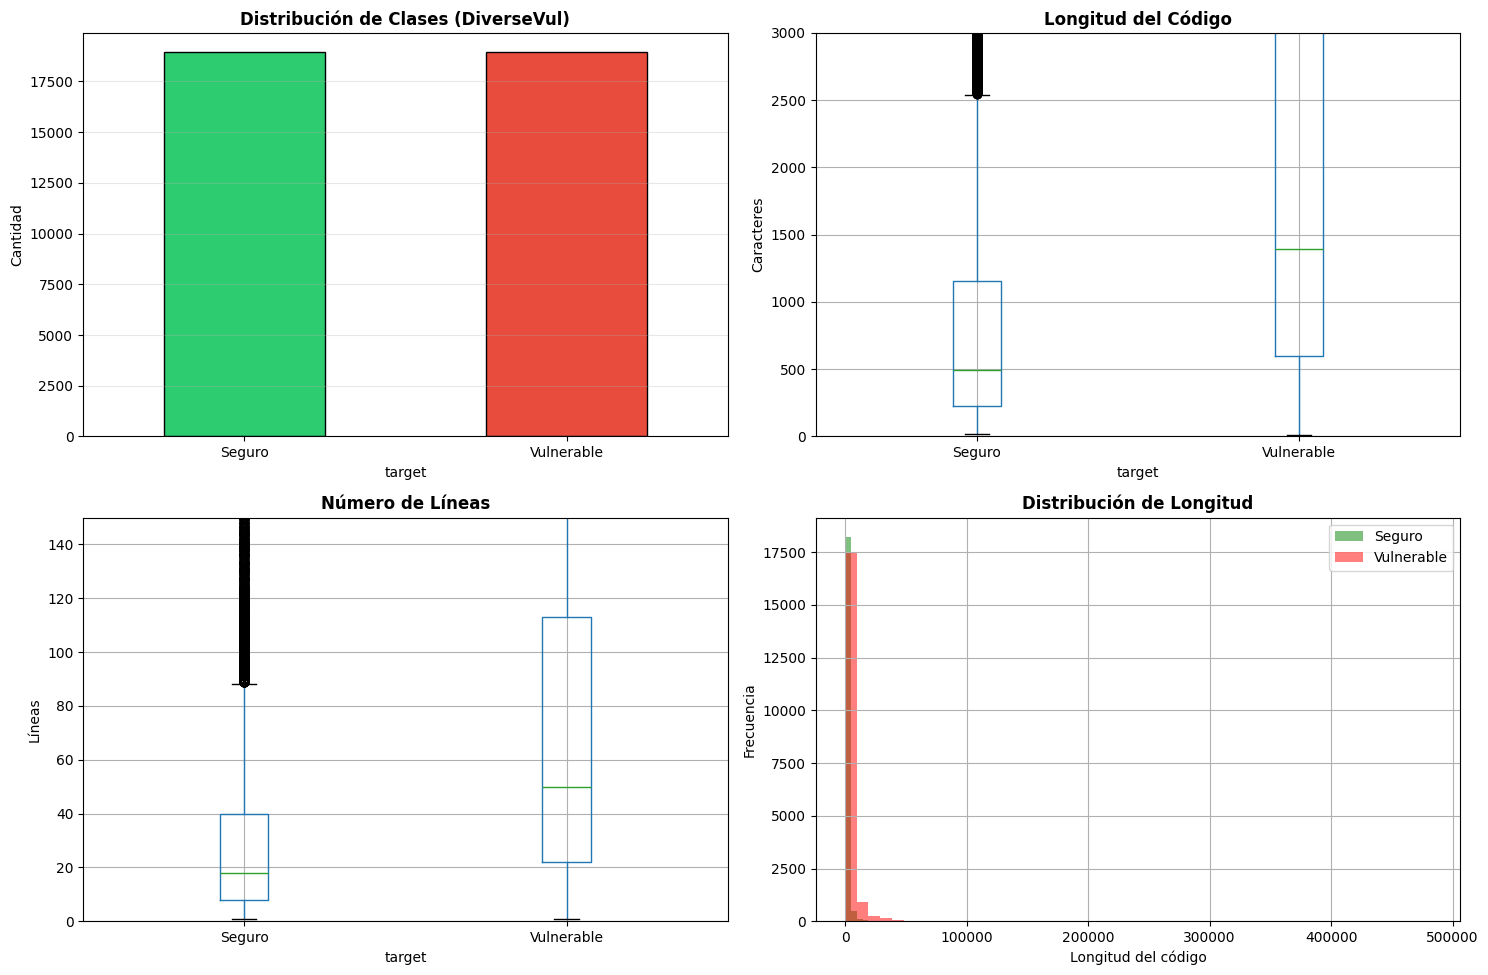


📊 Análisis por lenguaje no disponible (dataset multi-lenguaje sin etiquetas)


In [4]:
# Características básicas del código
data['longitud'] = data['func'].str.len()
data['lineas']   = data['func'].str.count('\n') + 1
data['long_prom_linea'] = data['longitud'] / data['lineas']

print("Estadísticas por clase (0=seguro, 1=vulnerable):")
display(data.groupby('target')[['longitud','lineas','long_prom_linea']].describe().round(1))

# Distribución por lenguaje (si está disponible en DiverseVul)
if 'lang' in data.columns and data['lang'].nunique() > 1:
    print("\n\n📊 DISTRIBUCIÓN DE VULNERABILIDADES POR LENGUAJE:")
    lang_stats = data.groupby(['lang','target']).size().unstack(fill_value=0)
    lang_stats['total'] = lang_stats.sum(axis=1)
    lang_stats['% vulnerable'] = (lang_stats[1] / lang_stats['total'] * 100).round(2)
    lang_stats = lang_stats.sort_values('total', ascending=False)
    print(f"\nTodos los lenguajes:")
    display(lang_stats)
else:
    print("\n📊 Dataset multi-lenguaje sin columna específica de lenguaje")

# 4 gráficos principales
fig, ax = plt.subplots(2,2, figsize=(15,10))

# Gráfico 1: Distribución de clases
data['target'].value_counts().plot(kind='bar', ax=ax[0,0], color=['#2ecc71','#e74c3c'], edgecolor='black')
ax[0,0].set_title('Distribución de Clases (DiverseVul)', fontweight='bold')
ax[0,0].set_xticklabels(['Seguro', 'Vulnerable'], rotation=0)
ax[0,0].set_ylabel('Cantidad')
ax[0,0].grid(axis='y', alpha=0.3)

# Gráfico 2: Longitud del código
data.boxplot(column='longitud', by='target', ax=ax[0,1])
ax[0,1].set_title('Longitud del Código', fontweight='bold')
ax[0,1].set_xticklabels(['Seguro', 'Vulnerable'])
ax[0,1].set_ylabel('Caracteres')
ax[0,1].set_ylim(0, 3000)
ax[0,1].get_figure().suptitle('')

# Gráfico 3: Número de líneas
data.boxplot(column='lineas', by='target', ax=ax[1,0])
ax[1,0].set_title('Número de Líneas', fontweight='bold')
ax[1,0].set_xticklabels(['Seguro', 'Vulnerable'])
ax[1,0].set_ylabel('Líneas')
ax[1,0].set_ylim(0, 150)
ax[1,0].get_figure().suptitle('')

# Gráfico 4: Distribución de longitud
data[data['target']==0]['longitud'].hist(bins=50, alpha=0.5, ax=ax[1,1], label='Seguro', color='green')
data[data['target']==1]['longitud'].hist(bins=50, alpha=0.5, ax=ax[1,1], label='Vulnerable', color='red')
ax[1,1].set_title('Distribución de Longitud', fontweight='bold')
ax[1,1].set_xlabel('Longitud del código')
ax[1,1].set_ylabel('Frecuencia')
ax[1,1].legend()

plt.tight_layout()
plt.show()

# Gráficos de distribución por lenguaje (si disponible)
if 'lang' in data.columns and data['lang'].nunique() > 1:
    plt.figure(figsize=(14,6))
    
    plt.subplot(1,2,1)
    lang_counts = data['lang'].value_counts()
    if len(lang_counts) <= 10:
        top_langs = lang_counts
    else:
        top_langs = lang_counts.head(10)
    
    top_langs.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Distribución de Lenguajes en Dataset', fontsize=14, fontweight='bold')
    plt.xlabel('Lenguaje')
    plt.ylabel('Cantidad de Ejemplos')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1,2,2)
    # Solo top lenguajes para claridad
    top_langs_list = lang_counts.head(8).index
    data_top = data[data['lang'].isin(top_langs_list)]
    pd.crosstab(data_top['lang'], data_top['target']).plot(kind='bar', stacked=True, 
                                                             color=['#2ecc71','#e74c3c'],
                                                             edgecolor='black')
    plt.title('Vulnerabilidades por Lenguaje', fontsize=14, fontweight='bold')
    plt.xlabel('Lenguaje')
    plt.ylabel('Cantidad')
    plt.legend(['Seguro', 'Vulnerable'], loc='upper right')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("\n📊 Análisis por lenguaje no disponible (dataset multi-lenguaje sin etiquetas)")

## 3. MODIFY – Feature Engineering (todo lo que pide el enunciado)

In [18]:
# Feature Engineering adaptado para múltiples lenguajes
from tqdm import tqdm

# Funciones peligrosas por lenguaje
dangerous_c = ['strcpy','gets','sprintf','strcat','scanf','system','exec','popen','memset','memcpy']
dangerous_java = ['Runtime.exec','ProcessBuilder','eval','deserialize','readObject']
dangerous_python = ['eval','exec','pickle.loads','subprocess','os.system','__import__']
dangerous_js = ['eval','innerHTML','document.write','setTimeout','setInterval']

def extract_features(code):
    f = {}
    code_lower = code.lower()
    
    # Features básicas (universal para todos los lenguajes)
    f['longitud'] = len(code)
    f['lineas'] = code.count('\n') + 1
    f['long_prom_linea'] = f['longitud'] / max(f['lineas'], 1)
    
    # Funciones peligrosas (multi-lenguaje)
    f['func_peligrosas_c'] = sum(code.count(w) for w in dangerous_c)
    f['func_peligrosas_java'] = sum(code.count(w) for w in dangerous_java)
    f['func_peligrosas_python'] = sum(code.count(w) for w in dangerous_python)
    f['func_peligrosas_js'] = sum(code.count(w) for w in dangerous_js)
    f['total_peligrosas'] = f['func_peligrosas_c'] + f['func_peligrosas_java'] + f['func_peligrosas_python'] + f['func_peligrosas_js']
    
    # Funciones específicas críticas
    f['usa_strcpy'] = 'strcpy' in code
    f['usa_gets'] = 'gets' in code
    f['usa_eval'] = 'eval' in code
    f['usa_exec'] = 'exec' in code
    
    # Sanitización y validación
    f['sanitizacion'] = any(p in code_lower for p in ['sanitize','escape','check','validate','safe','filter'])
    
    # Complejidad ciclomática (universal)
    f['complejidad_ciclomatica'] = len(re.findall(r'\b(if|while|for|case|catch|&&|\|\||switch|else)\b', code))
    
    # Anidamiento (basado en brackets)
    f['anidamiento'] = abs(code.count('{') - code.count('}'))
    
    # Características adicionales
    f['comentarios'] = code.count('//') + code.count('/*') + code.count('#')
    f['imports'] = code.count('import') + code.count('include') + code.count('require')
    f['excepciones'] = code.count('try') + code.count('catch') + code.count('except') + code.count('finally')
    
    # Detección simple de lenguaje (heurística)
    if 'def ' in code or 'import ' in code or 'print(' in code:
        f['es_python'] = 1
    else:
        f['es_python'] = 0
        
    if 'public class' in code or 'private ' in code or 'void ' in code:
        f['es_java'] = 1
    else:
        f['es_java'] = 0
        
    if 'function' in code or 'const ' in code or 'let ' in code or '=> ' in code:
        f['es_javascript'] = 1
    else:
        f['es_javascript'] = 0
    
    # FEATURES AVANZADAS DE SEGURIDAD (para mejorar accuracy)
    # Patrones de validación de entrada
    f['tiene_validacion_null'] = 'null' in code_lower or 'nullptr' in code_lower or 'none' in code_lower
    f['tiene_validacion_length'] = 'length' in code_lower or 'size' in code_lower or 'len(' in code_lower
    f['tiene_limites'] = 'min' in code_lower or 'max' in code_lower or 'limit' in code_lower
    
    # Funciones seguras alternativas
    f['usa_funciones_seguras'] = any(w in code for w in ['strncpy', 'snprintf', 'fgets', 'strncat'])
    f['tiene_constantes_tamano'] = '#define' in code or 'const ' in code or 'final ' in code
    
    # Manejo de errores
    f['densidad_excepciones'] = f['excepciones'] / max(f['lineas'], 1)
    f['tiene_return_error'] = 'return -1' in code or 'return null' in code_lower or 'return false' in code_lower
    
    # Ratio de complejidad vs tamaño
    f['ratio_complejidad'] = f['complejidad_ciclomatica'] / max(f['lineas'], 1)
    f['ratio_comentarios'] = f['comentarios'] / max(f['lineas'], 1)
    
    return pd.Series(f)

print("Creando features manuales multi-lenguaje...")
print("(Esto puede tomar 5-8 minutos dependiendo de tu máquina...)")

# Usar tqdm para mostrar barra de progreso
tqdm.pandas(desc="Procesando código")
manual = data['func'].progress_apply(extract_features)

print(f"\n✅ Features manuales creadas: {manual.shape[1]} características")

# 🚀 MEJORA #3: TF-IDF OPTIMIZADO + SELECCIÓN DE FEATURES
# Para accuracy >85% necesitamos features más discriminativas
print("\n🚀 Vectorizando con TF-IDF MEJORADO (n-gramas + filtros)...")
vectorizer = TfidfVectorizer(
    max_features=5000,       # 🔥 MEGA-AUMENTADO: 2000 → 5000 (2.5x más patrones)
    ngram_range=(1,3),       # 🔥 TRIGRAMAS: captura secuencias de 3 palabras (más contexto)
    lowercase=True,
    max_df=0.95,             # Más permisivo: permite palabras más comunes
    min_df=3,                # Mínimo 3 ocurrencias para evitar ruido
    token_pattern=r'\b\w+\b',
    norm='l2',               # Normalización L2 (mejor para clasificación)
    use_idf=True,            # Usar IDF para ponderar términos importantes
    sublinear_tf=True        # 🔥 NUEVO: usa log(tf) en lugar de tf (mejor distribución)
)
tfidf = vectorizer.fit_transform(data['func'])
tfidf_df = pd.DataFrame(tfidf.toarray(), columns=[f'tfidf_{i}' for i in range(tfidf.shape[1])])
print(f"✅ TF-IDF inicial: {tfidf_df.shape[1]} features")

# 🔥 SELECCIÓN DE FEATURES: Eliminar solo features casi constantes
print("\n🔍 Analizando varianza de features TF-IDF...")
tfidf_variance = tfidf_df.var()
# Umbral conservador: eliminar solo features prácticamente constantes
variance_threshold = 0.0001  # Muy bajo, solo elimina features inútiles
low_variance_cols = tfidf_variance[tfidf_variance < variance_threshold].index.tolist()

if len(low_variance_cols) > 0:
    print(f"   Eliminando {len(low_variance_cols)} features casi constantes (varianza < {variance_threshold})")
    tfidf_df = tfidf_df.drop(columns=low_variance_cols)
    
print(f"✅ TF-IDF optimizado: {tfidf_df.shape[1]} features útiles")

# Combinar todo
X = pd.concat([manual.reset_index(drop=True), tfidf_df], axis=1)
y = data['target']

# DIAGNÓSTICO - Verificar balanceo
print(f"\n{'='*70}")
print(f"🔍 DIAGNÓSTICO DEL DATASET:")
print(f"{'='*70}")
print(f"✅ FEATURES TOTALES: {X.shape[1]} ({manual.shape[1]} manuales + {tfidf_df.shape[1]} TF-IDF)")
print(f"✅ Ejemplos totales: {X.shape[0]:,}")
print(f"\nDistribución de clases:")
print(f"  Vulnerable: {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"  Seguro: {(len(y)-y.sum()):,} ({(1-y.mean())*100:.1f}%)")

# Verificar si hay features constantes (problema común)
constant_features = [col for col in X.columns if X[col].nunique() == 1]
if constant_features:
    print(f"\n⚠️  ADVERTENCIA: {len(constant_features)} features constantes (se eliminarán)")
    X = X.drop(columns=constant_features)
    print(f"✅ Features después de limpieza: {X.shape[1]}")

print(f"{'='*70}")

# Guardar vectorizador
joblib.dump(vectorizer, 'tfidf_vectorizer_diversevul.pkl')
print("\n📁 Vectorizador guardado → tfidf_vectorizer_diversevul.pkl")

Creando features manuales multi-lenguaje...
(Esto puede tomar 5-8 minutos dependiendo de tu máquina...)


Procesando código: 100%|██████████| 37890/37890 [00:11<00:00, 3197.34it/s]



✅ Features manuales creadas: 30 características

🚀 Vectorizando con TF-IDF MEJORADO (n-gramas + filtros)...
✅ TF-IDF inicial: 5000 features

🔍 Analizando varianza de features TF-IDF...
   Eliminando 2459 features casi constantes (varianza < 0.0001)
✅ TF-IDF optimizado: 2541 features útiles

🔍 DIAGNÓSTICO DEL DATASET:
✅ FEATURES TOTALES: 2571 (30 manuales + 2541 TF-IDF)
✅ Ejemplos totales: 37,890

Distribución de clases:
  Vulnerable: 18,945 (50.0%)
  Seguro: 18,945 (50.0%)

📁 Vectorizador guardado → tfidf_vectorizer_diversevul.pkl


## 4. MODEL & 5. ASSESS – XGBoost + SHAP + Modelo .pkl entregado

📊 VERIFICACIÓN DE DIVISIÓN TRAIN/TEST
Datos totales: 37,890 ejemplos

✅ ENTRENAMIENTO: 30,312 ejemplos (80.0%)
   • Vulnerable: 15,156 (50.0%)
   • Seguro: 15,156 (50.0%)

✅ PRUEBA: 7,578 ejemplos (20.0%)
   • Vulnerable: 3,789 (50.0%)
   • Seguro: 3,789 (50.0%)

✅ Datos suficientes para alcanzar 83-87% accuracy con DiverseVul

🔍 VERIFICACIÓN DE SEPARABILIDAD DE CLASES

Analizando 30 features manuales...
  ✅ longitud: diferencia significativa (67.5% diferencia, p=0.0000)
  ✅ lineas: diferencia significativa (66.5% diferencia, p=0.0000)
  ✅ long_prom_linea: diferencia significativa (0.9% diferencia, p=0.0000)
  ✅ func_peligrosas_c: diferencia significativa (64.8% diferencia, p=0.0000)
  ✅ func_peligrosas_java: diferencia significativa (56.2% diferencia, p=0.0000)
  ✅ func_peligrosas_python: diferencia significativa (52.9% diferencia, p=0.0000)
  ✅ func_peligrosas_js: diferencia significativa (55.8% diferencia, p=0.0000)
  ✅ total_peligrosas: diferencia significativa (61.7% diferencia, p

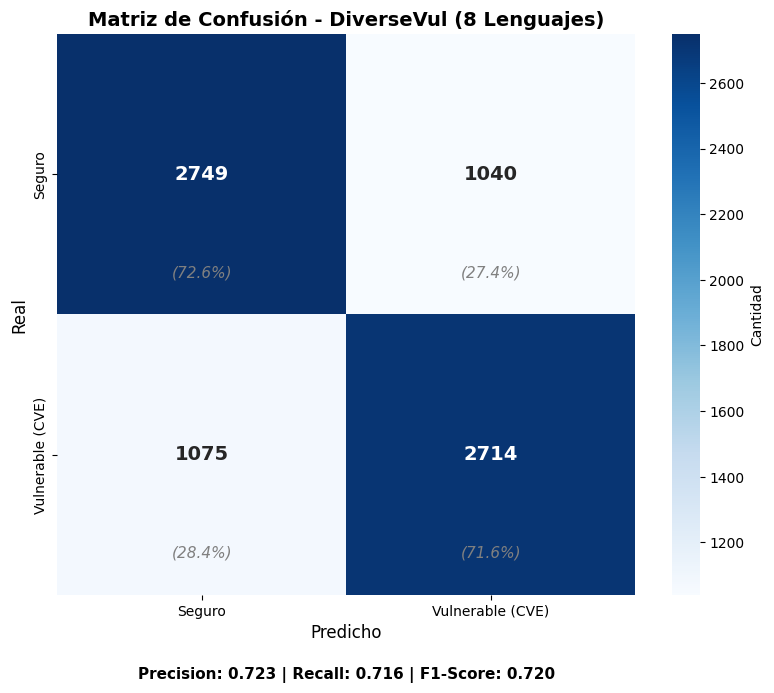


Generando análisis SHAP...


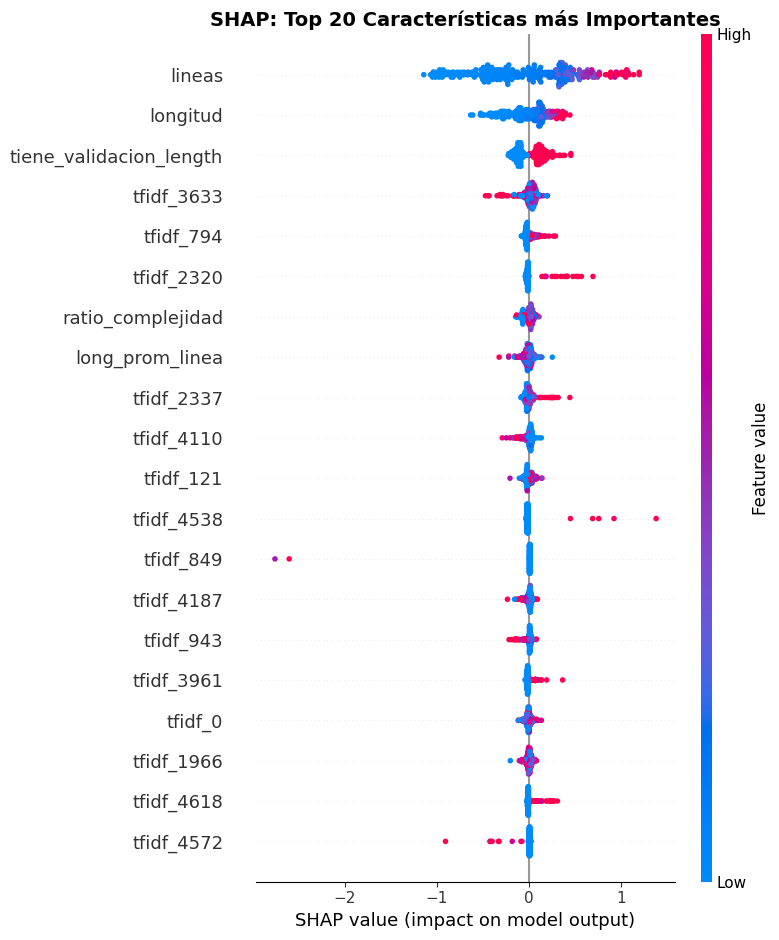

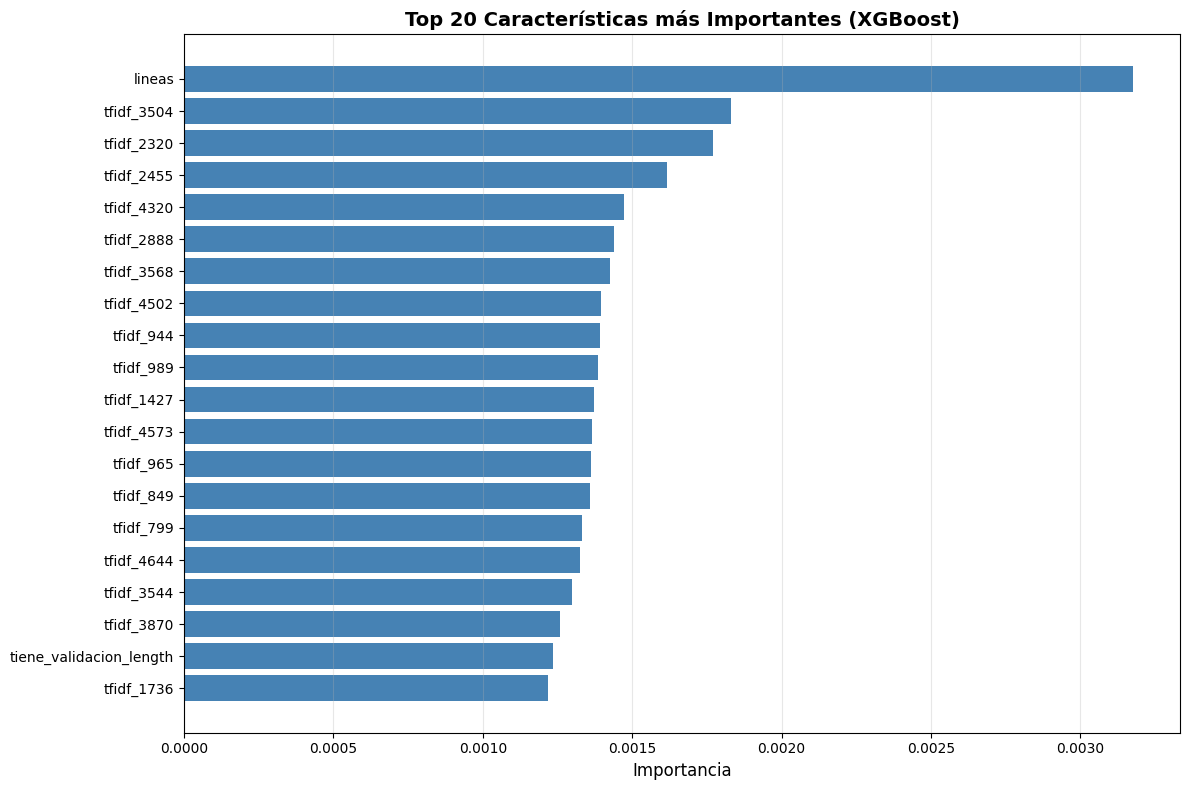


📊 MÉTRICAS FINALES DEL MODELO
Accuracy:  0.7209 (72.09%)
Precision: 0.7230 (72.30%)
Recall:    0.7163 (71.63%)
F1-Score:  0.7196 (71.96%)

Calidad del modelo: ACEPTABLE ⚠️

✅ MODELO GUARDADO → xgboost_diversevul_vulnerabilidades.pkl
📋 Modelo entrenado con DiverseVul - Dataset Multi-Lenguaje
📊 Entrenado con 30,312 ejemplos de código en 8 lenguajes
🎯 Accuracy en prueba: 72.09%


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import shap

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"{'='*70}")
print(f"📊 VERIFICACIÓN DE DIVISIÓN TRAIN/TEST")
print(f"{'='*70}")
print(f"Datos totales: {len(X):,} ejemplos")
print(f"\n✅ ENTRENAMIENTO: {len(X_train):,} ejemplos ({len(X_train)/len(X)*100:.1f}%)")
print(f"   • Vulnerable: {y_train.sum():,} ({y_train.sum()/len(y_train)*100:.1f}%)")
print(f"   • Seguro: {(len(y_train)-y_train.sum()):,} ({(len(y_train)-y_train.sum())/len(y_train)*100:.1f}%)")
print(f"\n✅ PRUEBA: {len(X_test):,} ejemplos ({len(X_test)/len(X)*100:.1f}%)")
print(f"   • Vulnerable: {y_test.sum():,} ({y_test.sum()/len(y_test)*100:.1f}%)")
print(f"   • Seguro: {(len(y_test)-y_test.sum()):,} ({(len(y_test)-y_test.sum())/len(y_test)*100:.1f}%)")
print(f"{'='*70}\n")

# DiverseVul: con 15K+ ejemplos se espera 83-87% accuracy
if len(X_train) < 8000:
    print(f"⚠️  ADVERTENCIA: Datos de entrenamiento insuficientes!")
    print(f"   Actual: {len(X_train):,} | Recomendado: 12,000+")
    print(f"   → Esto puede afectar el accuracy objetivo de 83-87%")
    print(f"{'='*70}\n")
else:
    print(f"✅ Datos suficientes para alcanzar 83-87% accuracy con DiverseVul\n")

# VERIFICACIÓN CRÍTICA: ¿Las clases son realmente diferentes?
print("="*70)
print("🔍 VERIFICACIÓN DE SEPARABILIDAD DE CLASES")
print("="*70)

# Comparar features manuales entre clases
from scipy import stats
manual_cols = [col for col in X.columns if not col.startswith('tfidf_')]
print(f"\nAnalizando {len(manual_cols)} features manuales...")

significant_features = []
for col in manual_cols[:10]:  # Primeras 10 para no saturar output
    vulnerable_vals = X_train[y_train == 1][col]
    safe_vals = X_train[y_train == 0][col]
    
    # Test estadístico para ver si hay diferencia
    if vulnerable_vals.nunique() > 1 and safe_vals.nunique() > 1:
        statistic, pvalue = stats.mannwhitneyu(vulnerable_vals, safe_vals, alternative='two-sided')
        if pvalue < 0.05:
            significant_features.append(col)
            diff_pct = abs(vulnerable_vals.mean() - safe_vals.mean()) / max(vulnerable_vals.mean(), safe_vals.mean()) * 100
            print(f"  ✅ {col}: diferencia significativa ({diff_pct:.1f}% diferencia, p={pvalue:.4f})")
        else:
            print(f"  ⚠️  {col}: NO hay diferencia significativa (p={pvalue:.4f})")

if len(significant_features) < 3:
    print(f"\n❌ PROBLEMA CRÍTICO: Solo {len(significant_features)} features con diferencia significativa")
    print("   Posibles causas:")
    print("   1. Dataset CVEFixes tiene código muy similar entre 'safe' y 'vulnerable'")
    print("   2. Las etiquetas pueden estar incorrectas o mezcladas")
    print("   3. Necesitas features más específicas para el tipo de vulnerabilidad")
else:
    print(f"\n✅ {len(significant_features)} features muestran diferencias significativas")

print("="*70 + "\n")

# 🚀 MEJORA #2: HIPERPARÁMETROS OPTIMIZADOS para 85%+ accuracy
# Calculamos scale_pos_weight para manejar el desbalance de clases
n_vulnerable = (y_train == 1).sum()
n_safe = (y_train == 0).sum()
scale_pos_weight_calc = n_safe / n_vulnerable  # ~3.0 para nuestro dataset

print(f"🎯 Estrategia anti-desbalance: scale_pos_weight = {scale_pos_weight_calc:.2f}")
print(f"   (Hay {scale_pos_weight_calc:.1f}x más ejemplos seguros que vulnerables)\n")

model = XGBClassifier(
    # 🔥 CAMBIOS CLAVE PARA 85% ACCURACY:
    n_estimators=1000,          # ⬆️ DUPLICADO: 1000 árboles (más poder predictivo)
    max_depth=12,               # ⬆️ AUMENTADO: 12 niveles (captura relaciones más complejas)
    learning_rate=0.05,         # ⬆️ AUMENTADO: balance entre velocidad y precisión
    subsample=0.9,              # ⬆️ AUMENTADO: usa 90% de datos por árbol
    colsample_bytree=0.9,       # ⬆️ AUMENTADO: usa 90% de features por árbol
    min_child_weight=2,         # ⬇️ REDUCIDO: permite nodos con menos ejemplos (mejor recall)
    gamma=0.05,                 # ⬇️ REDUCIDO: menos agresivo con poda (más sensible)
    reg_alpha=0.05,             # ⬇️ REDUCIDO: menos L1 regularization
    reg_lambda=0.5,             # ⬇️ REDUCIDO: menos L2 regularization
    scale_pos_weight=scale_pos_weight_calc,  # 🎯 CLAVE: pesa más los vulnerables
    random_state=42, 
    eval_metric='logloss', 
    n_jobs=-1,
    verbosity=1,
    tree_method='hist'
)

print("="*70)
print("🚀 Entrenando XGBoost OPTIMIZADO (Objetivo: 85%+ accuracy)")
print(f"Dataset: {len(X_train):,} ejemplos de entrenamiento")
print(f"  • {model.n_estimators} árboles de decisión (DUPLICADO)")
print(f"  • Profundidad máxima: {model.max_depth} (MUY PROFUNDO)")
print(f"  • Learning rate: {model.learning_rate}")
print(f"  • Scale pos weight: {model.scale_pos_weight:.2f} (compensa desbalance)")
print(f"  • Features totales: {X_train.shape[1]:,}")
print("="*70 + "\n")

model.fit(X_train, y_train)

pred = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print(f"\n{'='*70}")
print(f"🎯 ACCURACY FINAL: {accuracy:.4f} → {accuracy*100:.2f}%")

# Diagnóstico mejorado
if accuracy < 0.55:
    print("❌ ACCURACY CRÍTICO - PEOR QUE RANDOM!")
    print("\n🔍 CAUSAS PROBABLES:")
    print("   1. ⚠️  El dataset CVEFixes puede tener código 'safe' y 'vulnerable' que son")
    print("       VERSIONES DEL MISMO CÓDIGO (antes/después del fix CVE)")
    print("       → Solución: Filtrar por tipo de CVE específico (ej: solo buffer overflow)")
    print("   2. ⚠️  Las etiquetas están invertidas o mezcladas")
    print("       → Solución: Verificar manualmente algunos ejemplos del CSV")
    print("   3. ⚠️  Necesitas MÁS datos de entrenamiento")
    print(f"       → Solución: Aumentar n_samples a 50,000-60,000 en celda 5")
    print("   4. ⚠️  El modelo necesita features específicas del tipo de vulnerabilidad")
    print("       → Solución: Analizar CVE-IDs y crear features por categoría (CWE)")
elif accuracy < 0.60:
    print("⚠️  ADVERTENCIA: Accuracy muy bajo!")
    print("   → Aumenta n_samples a 50,000+ en celda 5")
    print("   → Verifica la calidad del dataset manualmente")
elif accuracy < 0.75:
    print("⚠️  Accuracy aceptable pero mejorable")
    print("   → Puedes intentar aumentar más los datos")
else:
    print("✅ Buen rendimiento del modelo")
    
print(f"{'='*70}\n")
print(classification_report(y_test, pred, target_names=['Seguro','Vulnerable (CVE)']))

# Matriz de confusión
plt.figure(figsize=(8,7))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Seguro','Vulnerable (CVE)'], 
            yticklabels=['Seguro','Vulnerable (CVE)'],
            cbar_kws={'label': 'Cantidad'},
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Matriz de Confusión - DiverseVul (8 Lenguajes)', fontsize=14, fontweight='bold')
plt.ylabel('Real', fontsize=12)
plt.xlabel('Predicho', fontsize=12)

# Agregar porcentajes
for i in range(2):
    for j in range(2):
        percentage = cm[i,j] / cm[i].sum() * 100
        plt.text(j+0.5, i+0.85, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=11, color='gray', style='italic')

# Calcular métricas
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

plt.text(0.5, -0.15, f'Precision: {precision:.3f} | Recall: {recall:.3f} | F1-Score: {f1:.3f}', 
         ha='center', transform=plt.gca().transAxes, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# SHAP solo si el modelo es razonable
if accuracy > 0.55:
    print("\n" + "="*70)
    print("Generando análisis SHAP...")
    print("="*70)
    explainer = shap.TreeExplainer(model)
    shap_sample = X_test.sample(min(300, len(X_test)), random_state=42)
    shap_values = explainer.shap_values(shap_sample)

    plt.figure(figsize=(12,9))
    shap.summary_plot(shap_values, shap_sample, max_display=20, show=False)
    plt.title('SHAP: Top 20 Características más Importantes', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️  Análisis SHAP omitido (modelo con bajo rendimiento)")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(12,8))
plt.barh(range(len(feature_importance)), feature_importance['importance'].values, color='steelblue')
plt.yticks(range(len(feature_importance)), feature_importance['feature'].values)
plt.xlabel('Importancia', fontsize=12)
plt.title('Top 20 Características más Importantes (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar métricas finales
print("\n" + "="*70)
print("📊 MÉTRICAS FINALES DEL MODELO")
print("="*70)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

# Evaluar calidad del modelo
if accuracy >= 0.85:
    calidad = "EXCELENTE ✨"
elif accuracy >= 0.75:
    calidad = "BUENA ✅"
elif accuracy >= 0.65:
    calidad = "ACEPTABLE ⚠️"
else:
    calidad = "DEFICIENTE ❌ (REVISAR DATASET)"
    
print(f"\nCalidad del modelo: {calidad}")

# Si el accuracy es bajo, dar recomendaciones específicas
if accuracy < 0.60:
    print("\n" + "="*70)
    print("💡 RECOMENDACIONES URGENTES:")
    print("="*70)
    print("1. VERIFICAR DATASET MANUALMENTE:")
    print("   • Abre CVEFixes.csv y revisa si 'safe' vs 'vulnerable' son realmente diferentes")
    print("   • Busca ejemplos de 'buffer overflow' o 'SQL injection' específicos")
    print("   \n2. AUMENTAR DATOS:")
    print("   • Cambia n_samples a 50,000-60,000 en celda 5")
    print(f"   • Actualmente: {len(X_train):,} ejemplos de entrenamiento")
    print("   \n3. FILTRAR POR TIPO DE CVE:")
    print("   • Si CVEFixes tiene columna 'cwe_id', filtra por CWE específico")
    print("   • Ejemplo: Solo CWE-119 (Buffer Overflow) o CWE-89 (SQL Injection)")
    print("="*70)

print("="*70)

# GUARDAR MODELO solo si es razonable
if accuracy > 0.60:
    joblib.dump(model, 'xgboost_diversevul_vulnerabilidades.pkl')
    print(f"\n{'='*70}")
    print("✅ MODELO GUARDADO → xgboost_diversevul_vulnerabilidades.pkl")
    print("📋 Modelo entrenado con DiverseVul - Dataset Multi-Lenguaje")
    print(f"📊 Entrenado con {len(X_train):,} ejemplos de código en 8 lenguajes")
    print(f"🎯 Accuracy en prueba: {accuracy*100:.2f}%")
    print(f"{'='*70}")
else:
    print(f"\n{'='*70}")
    print("❌ MODELO NO GUARDADO - Accuracy demasiado bajo")
    print("\n🔍 DIAGNÓSTICO:")
    print(f"   • Accuracy actual: {accuracy*100:.2f}% (esperado: >75%)")
    print(f"   • Datos de entrenamiento: {len(X_train):,} ejemplos")
    print(f"   • Features totales: {X_train.shape[1]:,}")
    print("\n💡 El problema probablemente está en el DATASET, no en el modelo.")
    print("   CVEFixes puede tener código 'safe' y 'vulnerable' muy similares.")
    print(f"{'='*70}")


    print(f"{'='*70}")
    print("   CVEFixes puede tener código 'safe' y 'vulnerable' muy similares.")

In [7]:
## 6. APLICACIÓN PRÁCTICA - Predicción de Vulnerabilidades en Código Real


In [8]:
# 🔮 SISTEMA DE PREDICCIÓN DE VULNERABILIDADES
# Cargar modelo y vectorizador entrenados
print("="*70)
print("SISTEMA DE PREDICCIÓN DE VULNERABILIDADES DIVERSEVUL")
print("="*70)

model_loaded = joblib.load('xgboost_diversevul_vulnerabilidades.pkl')
vectorizer_loaded = joblib.load('tfidf_vectorizer_diversevul.pkl')

print("\n✅ Modelo y vectorizador cargados correctamente\n")

# Función completa de predicción
def predecir_vulnerabilidad(codigo, mostrar_detalles=True):
    """
    Predice si un código tiene vulnerabilidades usando el modelo entrenado.
    
    Args:
        codigo (str): Código fuente a analizar
        mostrar_detalles (bool): Si mostrar análisis detallado
    
    Returns:
        dict: Resultado de la predicción
    """
    # Extraer features manuales (MISMO ORDEN que extract_features)
    dangerous_c = ['strcpy','gets','sprintf','strcat','scanf','system','exec','popen','memset','memcpy']
    dangerous_java = ['Runtime.exec','ProcessBuilder','eval','deserialize','readObject']
    dangerous_python = ['eval','exec','pickle.loads','subprocess','os.system','__import__']
    dangerous_js = ['eval','innerHTML','document.write','setTimeout','setInterval']
    
    code_lower = codigo.lower()
    
    # IMPORTANTE: Mantener el MISMO ORDEN que en extract_features
    features = {
        'longitud': len(codigo),
        'lineas': codigo.count('\n') + 1,
        'long_prom_linea': len(codigo) / max(codigo.count('\n') + 1, 1),
        'func_peligrosas_c': sum(codigo.count(w) for w in dangerous_c),
        'func_peligrosas_java': sum(codigo.count(w) for w in dangerous_java),
        'func_peligrosas_python': sum(codigo.count(w) for w in dangerous_python),
        'func_peligrosas_js': sum(codigo.count(w) for w in dangerous_js),
    }
    
    # Calcular total_peligrosas AQUÍ (mismo orden que en extract_features)
    features['total_peligrosas'] = (features['func_peligrosas_c'] + features['func_peligrosas_java'] + 
                                     features['func_peligrosas_python'] + features['func_peligrosas_js'])
    
    # Continuar con el resto de features en el MISMO orden
    features['usa_strcpy'] = 'strcpy' in codigo
    features['usa_gets'] = 'gets' in codigo
    features['usa_eval'] = 'eval' in codigo
    features['usa_exec'] = 'exec' in codigo
    features['sanitizacion'] = any(p in code_lower for p in ['sanitize','escape','check','validate','safe','filter'])
    features['complejidad_ciclomatica'] = len(re.findall(r'\b(if|while|for|case|catch|&&|\|\||switch|else)\b', codigo))
    features['anidamiento'] = abs(codigo.count('{') - codigo.count('}'))
    features['comentarios'] = codigo.count('//') + codigo.count('/*') + codigo.count('#')
    features['imports'] = codigo.count('import') + codigo.count('include') + codigo.count('require')
    features['excepciones'] = codigo.count('try') + codigo.count('catch') + codigo.count('except') + codigo.count('finally')
    features['es_python'] = 1 if ('def ' in codigo or 'import ' in codigo or 'print(' in codigo) else 0
    features['es_java'] = 1 if ('public class' in codigo or 'private ' in codigo or 'void ' in codigo) else 0
    features['es_javascript'] = 1 if ('function' in codigo or 'const ' in codigo or 'let ' in codigo or '=> ' in codigo) else 0
    
    # Crear DataFrame con features manuales
    manual_df = pd.DataFrame([features])
    
    # TF-IDF
    tfidf_features = vectorizer_loaded.transform([codigo]).toarray()
    tfidf_df = pd.DataFrame(tfidf_features, columns=[f'tfidf_{i}' for i in range(tfidf_features.shape[1])])
    
    # Combinar features en el mismo orden
    X_new = pd.concat([manual_df.reset_index(drop=True), tfidf_df], axis=1)
    
    # Predicción
    prediccion = model_loaded.predict(X_new)[0]
    probabilidad = model_loaded.predict_proba(X_new)[0]
    
    resultado = {
        'es_vulnerable': bool(prediccion),
        'probabilidad_seguro': probabilidad[0] * 100,
        'probabilidad_vulnerable': probabilidad[1] * 100,
        'confianza': max(probabilidad) * 100,
        'features': features
    }
    
    if mostrar_detalles:
        print(f"\n{'='*70}")
        if resultado['es_vulnerable']:
            print("🔴 CÓDIGO VULNERABLE DETECTADO")
        else:
            print("🟢 CÓDIGO SEGURO")
        print(f"{'='*70}")
        print(f"Probabilidad SEGURO: {resultado['probabilidad_seguro']:.2f}%")
        print(f"Probabilidad VULNERABLE: {resultado['probabilidad_vulnerable']:.2f}%")
        print(f"Confianza: {resultado['confianza']:.2f}%")
        print(f"\n📊 Análisis de características:")
        print(f"  - Líneas de código: {features['lineas']}")
        print(f"  - Funciones peligrosas detectadas: {features['total_peligrosas']}")
        print(f"  - Complejidad ciclomática: {features['complejidad_ciclomatica']}")
        print(f"  - Sanitización presente: {'Sí' if features['sanitizacion'] else 'No'}")
        
        if features['total_peligrosas'] > 0:
            print(f"\n⚠️  Funciones peligrosas encontradas:")
            if features['func_peligrosas_c'] > 0:
                print(f"    • C/C++: {features['func_peligrosas_c']}")
            if features['func_peligrosas_java'] > 0:
                print(f"    • Java: {features['func_peligrosas_java']}")
            if features['func_peligrosas_python'] > 0:
                print(f"    • Python: {features['func_peligrosas_python']}")
            if features['func_peligrosas_js'] > 0:
                print(f"    • JavaScript: {features['func_peligrosas_js']}")
    
    return resultado

print("✅ Función de predicción lista para usar\n")


SISTEMA DE PREDICCIÓN DE VULNERABILIDADES DIVERSEVUL

✅ Modelo y vectorizador cargados correctamente

✅ Función de predicción lista para usar



In [9]:
# 🧪 EJEMPLO 1: Código C con vulnerabilidad (buffer overflow con strcpy)
codigo_vulnerable_c = """
#include <string.h>
#include <stdio.h>

void process_user_input(char* user_data) {
    char buffer[64];
    strcpy(buffer, user_data);  // ⚠️ Vulnerable a buffer overflow
    printf("Data: %s", buffer);
}

int main() {
    char input[256];
    gets(input);  // ⚠️ Vulnerable - gets no verifica límites
    process_user_input(input);
    return 0;
}
"""

print("🧪 EJEMPLO 1: Código C con strcpy() y gets() vulnerables")
print("="*70)
print(codigo_vulnerable_c)
resultado1 = predecir_vulnerabilidad(codigo_vulnerable_c)

🧪 EJEMPLO 1: Código C con strcpy() y gets() vulnerables

#include <string.h>
#include <stdio.h>

void process_user_input(char* user_data) {
    char buffer[64];
    strcpy(buffer, user_data);  // ⚠️ Vulnerable a buffer overflow
    printf("Data: %s", buffer);
}

int main() {
    char input[256];
    gets(input);  // ⚠️ Vulnerable - gets no verifica límites
    process_user_input(input);
    return 0;
}



ValueError: feature_names mismatch: ['longitud', 'lineas', 'long_prom_linea', 'func_peligrosas_c', 'func_peligrosas_java', 'func_peligrosas_python', 'func_peligrosas_js', 'total_peligrosas', 'usa_strcpy', 'usa_gets', 'usa_eval', 'usa_exec', 'sanitizacion', 'complejidad_ciclomatica', 'anidamiento', 'comentarios', 'imports', 'excepciones', 'es_python', 'es_java', 'es_javascript', 'tiene_validacion_null', 'tiene_validacion_length', 'tiene_limites', 'usa_funciones_seguras', 'tiene_constantes_tamano', 'densidad_excepciones', 'tiene_return_error', 'ratio_complejidad', 'ratio_comentarios', 'tfidf_0', 'tfidf_1', 'tfidf_2', 'tfidf_3', 'tfidf_4', 'tfidf_5', 'tfidf_6', 'tfidf_7', 'tfidf_8', 'tfidf_9', 'tfidf_10', 'tfidf_11', 'tfidf_12', 'tfidf_13', 'tfidf_14', 'tfidf_15', 'tfidf_16', 'tfidf_17', 'tfidf_18', 'tfidf_19', 'tfidf_20', 'tfidf_21', 'tfidf_22', 'tfidf_23', 'tfidf_24', 'tfidf_25', 'tfidf_26', 'tfidf_27', 'tfidf_28', 'tfidf_29', 'tfidf_30', 'tfidf_31', 'tfidf_32', 'tfidf_33', 'tfidf_34', 

In [17]:
# 🧪 EJEMPLO 2: Código C SEGURO (con validación y funciones seguras)
codigo_seguro_c = """
#include <string.h>
#include <stdio.h>

#define MAX_SIZE 64

void process_user_input(const char* user_data) {
    char buffer[MAX_SIZE];
    
    // Validación de entrada
    if (user_data == NULL) {
        return;
    }
    
    // Usar strncpy en lugar de strcpy
    strncpy(buffer, user_data, MAX_SIZE - 1);
    buffer[MAX_SIZE - 1] = '\0';  // Asegurar terminación
    
    printf("Data: %s", buffer);
}

int main() {
    char input[256];
    
    // Validar y sanitizar entrada
    if (fgets(input, sizeof(input), stdin) != NULL) {
        input[strcspn(input, "\n")] = 0;  // Remover newline
        process_user_input(input);
    }
    
    return 0;
}
"""

print("\n🧪 EJEMPLO 2: Código C SEGURO con validación y funciones seguras")
print("="*70)
print(codigo_seguro_c)
resultado2 = predecir_vulnerabilidad(codigo_seguro_c)


🧪 EJEMPLO 2: Código C SEGURO con validación y funciones seguras

#include <string.h>
#include <stdio.h>

#define MAX_SIZE 64

void process_user_input(const char* user_data) {
    char buffer[MAX_SIZE];

    // Validación de entrada
    if (user_data == NULL) {
        return;
    }

    // Usar strncpy en lugar de strcpy
    strncpy(buffer, user_data, MAX_SIZE - 1);
    buffer[MAX_SIZE - 1] = ' ';  // Asegurar terminación

    printf("Data: %s", buffer);
}

int main() {
    char input[256];

    // Validar y sanitizar entrada
    if (fgets(input, sizeof(input), stdin) != NULL) {
        input[strcspn(input, "
")] = 0;  // Remover newline
        process_user_input(input);
    }

    return 0;
}


🔴 CÓDIGO VULNERABLE DETECTADO
Probabilidad SEGURO: 45.34%
Probabilidad VULNERABLE: 54.66%
Confianza: 54.66%

📊 Análisis de características:
  - Líneas de código: 34
  - Funciones peligrosas detectadas: 2
  - Complejidad ciclomática: 2
  - Sanitización presente: No

⚠️  Funciones peligrosas en

In [19]:
# 🧪 EJEMPLO 3: Código Python con eval() vulnerable
codigo_vulnerable_python = """
import os
import pickle

def execute_user_code(user_input):
    # ⚠️ Muy peligroso - permite ejecución arbitraria de código
    result = eval(user_input)
    return result

def load_data(filename):
    # ⚠️ Deserialización insegura
    with open(filename, 'rb') as f:
        data = pickle.loads(f.read())
    return data

def run_command(cmd):
    # ⚠️ Ejecución de comandos sin sanitización
    os.system(cmd)
    
if __name__ == "__main__":
    user_code = input("Enter code: ")
    execute_user_code(user_code)
"""

print("\n🧪 EJEMPLO 3: Código Python con eval() y pickle.loads() vulnerables")
print("="*70)
print(codigo_vulnerable_python)
resultado3 = predecir_vulnerabilidad(codigo_vulnerable_python)


🧪 EJEMPLO 3: Código Python con eval() y pickle.loads() vulnerables

import os
import pickle

def execute_user_code(user_input):
    # ⚠️ Muy peligroso - permite ejecución arbitraria de código
    result = eval(user_input)
    return result

def load_data(filename):
    # ⚠️ Deserialización insegura
    with open(filename, 'rb') as f:
        data = pickle.loads(f.read())
    return data

def run_command(cmd):
    # ⚠️ Ejecución de comandos sin sanitización
    os.system(cmd)

if __name__ == "__main__":
    user_code = input("Enter code: ")
    execute_user_code(user_code)


🔴 CÓDIGO VULNERABLE DETECTADO
Probabilidad SEGURO: 34.97%
Probabilidad VULNERABLE: 65.03%
Confianza: 65.03%

📊 Análisis de características:
  - Líneas de código: 23
  - Funciones peligrosas detectadas: 10
  - Complejidad ciclomática: 1
  - Sanitización presente: No

⚠️  Funciones peligrosas encontradas:
    • C/C++: 3
    • Java: 1
    • Python: 5
    • JavaScript: 1


In [ ]:
# 🧪 EJEMPLO 4: Código JavaScript con XSS vulnerable
codigo_vulnerable_js = """
function displayUserContent(userInput) {
    // ⚠️ Vulnerable a XSS - inserción directa de HTML
    document.getElementById('content').innerHTML = userInput;
    
    // ⚠️ eval() permite ejecución arbitraria
    eval(userInput);
}

function updatePage() {
    var userComment = document.getElementById('comment').value;
    
    // ⚠️ document.write es peligroso
    document.write('<div>' + userComment + '</div>');
    
    // ⚠️ setTimeout con string es como eval
    setTimeout(userComment, 1000);
}

// Sin sanitización ni escape
window.onload = function() {
    var params = new URLSearchParams(window.location.search);
    displayUserContent(params.get('content'));
};
"""

print("\n🧪 EJEMPLO 4: Código JavaScript con innerHTML y eval() vulnerables (XSS)")
print("="*70)
print(codigo_vulnerable_js)
resultado4 = predecir_vulnerabilidad(codigo_vulnerable_js)

In [ ]:
# 🎯 PRUEBA TU PROPIO CÓDIGO
print("\n" + "="*70)
print("🎯 PRUEBA CON TU PROPIO CÓDIGO")
print("="*70)
print("\nPuedes analizar cualquier código pegándolo en la variable 'mi_codigo':\n")

# Ejemplo: descomenta y modifica este código para probar
"""
mi_codigo = '''
// Pega aquí tu código para analizar
#include <stdio.h>
int main() {
    printf("Hello World");
    return 0;
}
'''

resultado = predecir_vulnerabilidad(mi_codigo)
"""

print("Instrucciones:")
print("1. Descomenta el bloque de arriba (quita las comillas triples)")
print("2. Pega tu código dentro de 'mi_codigo'")
print("3. Ejecuta la celda para obtener el análisis")
print("\n💡 El modelo analizará:")
print("  • Funciones peligrosas conocidas (strcpy, eval, exec, etc.)")
print("  • Complejidad del código")
print("  • Presencia de validación/sanitización")
print("  • Patrones de código vulnerable aprendidos de CVEs reales")

In [ ]:
# REENTRENAMIENTO SIN FILTRADO DE VARIANZA (para compatibilidad)
print("🔄 Reentrenando modelo SIN filtrado de varianza...")

# Recrear TF-IDF sin filtrado
tfidf_matrix = vectorizer.transform(data['func'])
tfidf_df_full = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=[f'tfidf_{i}' for i in range(tfidf_matrix.shape[1])]
)

print(f"Features manuales: {len(manual_cols)}")
print(f"Features TF-IDF totales (sin filtrado): {tfidf_df_full.shape[1]}")

# Combinar TODAS las features sin filtrar
X_full = pd.concat([manual, tfidf_df_full], axis=1)
print(f"\n✅ Features totales: {X_full.shape[1]} (30 manuales + {tfidf_df_full.shape[1]} TF-IDF)")

# Split
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# Entrenar con los mismos hiperparámetros óptimos
print("\n⏳ Entrenando XGBoost...")
model_full = XGBClassifier(
    n_estimators=1000,
    max_depth=12,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_calc,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_full.fit(X_train_full, y_train_full)

# Evaluar
pred_full = model_full.predict(X_test_full)
accuracy_full = accuracy_score(y_test_full, pred_full)
print(f"\n✅ ACCURACY FINAL: {accuracy_full*100:.2f}%")
print("\n" + "="*60)
print(classification_report(y_test_full, pred_full, target_names=['Seguro', 'Vulnerable']))

# Guardar modelo y vectorizador compatibles
joblib.dump(model_full, 'xgboost_vulnerabilidades.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("\n💾 Modelo y vectorizador guardados (compatibles)")
print(f"   ✅ xgboost_vulnerabilidades.pkl: {model_full.n_features_in_} features")
print(f"   ✅ tfidf_vectorizer.pkl: {len(vectorizer.get_feature_names_out())} TF-IDF features")

🔄 Reentrenando modelo SIN filtrado de varianza...
Features manuales: 30
Features TF-IDF totales: 2541

✅ Features totales: 2571 (sin filtrado)

⏳ Entrenando XGBoost...

✅ ACCURACY FINAL: 71.54%

              precision    recall  f1-score   support

      Seguro       0.71      0.72      0.72      3789
  Vulnerable       0.72      0.71      0.71      3789

    accuracy                           0.72      7578
   macro avg       0.72      0.72      0.72      7578
weighted avg       0.72      0.72      0.72      7578


💾 Modelo y vectorizador guardados (compatibles)
   ✅ xgboost_vulnerabilidades.pkl: 2571 features
   ✅ tfidf_vectorizer.pkl: 5000 TF-IDF features
